In [17]:
# Import thư viện
from google.cloud import bigquery
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [18]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [19]:
client = bigquery.Client(project="bi-recruitment-452004")

Các thay đổi được ghi nhận trong tuần Retention Rate D3 giảm:
- Game update version mới
- A/B Test
- UA mở rộng country sang Tier 2/3 kèm tăng spend

In [20]:
# SELECT
#   user_pseudo_id,
#   install_date,
#   CASE
#     WHEN install_date BETWEEN '2026-03-10' AND '2026-03-23' THEN 'before'
#     WHEN install_date BETWEEN '2026-03-24' AND '2026-04-05' THEN 'after'
#   END AS period,
#   UPPER(operating_system) AS os,
#   country,
#   tier,
#   version,
#   traffic_source_medium,
#   traffic_source_source,
#   _0, _1, _2, _3, _4, _5, _6, _7, _14, _30
# FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
# WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
# AND install_date IS NOT NULL
# ORDER BY install_date ASC;

In [21]:
# Tính RR theo Paid và Organic
traffic_base_query = """WITH base AS (
  SELECT
    user_pseudo_id,
    install_date,
    CASE
      WHEN install_date BETWEEN '2026-03-10' AND '2026-03-23' THEN 'before'
      WHEN install_date BETWEEN '2026-03-24' AND '2026-04-05' THEN 'after'
    END AS period,
    UPPER(operating_system) AS os,
    country,
    tier,
    version,
    traffic_source_medium,
    traffic_source_source,
    _0, _1, _2, _3, _4, _5, _6, _7, _14, _30
  FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
  WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
  AND install_date IS NOT NULL
  ORDER BY install_date ASC
)

SELECT
  CASE 
    WHEN traffic_source_medium IS NULL OR traffic_source_medium IN ('Unknown Devices', 'Untrusted Devices') THEN 'Organic'
    ELSE 'Paid' 
  END AS traffic_source_medium,
  install_date,
  period,
  os,
  COUNT(user_pseudo_id) AS total_installs,
  ROUND(SAFE_DIVIDE(SUM(_1), COUNT(user_pseudo_id)) * 100, 2) AS rr_d1,
  ROUND(SAFE_DIVIDE(SUM(_3), COUNT(user_pseudo_id)) * 100, 2) AS rr_d3
FROM base
GROUP BY install_date, traffic_source_medium, period, os
ORDER BY install_date, os;
""" 
df_traffic = client.query(traffic_base_query).to_dataframe()

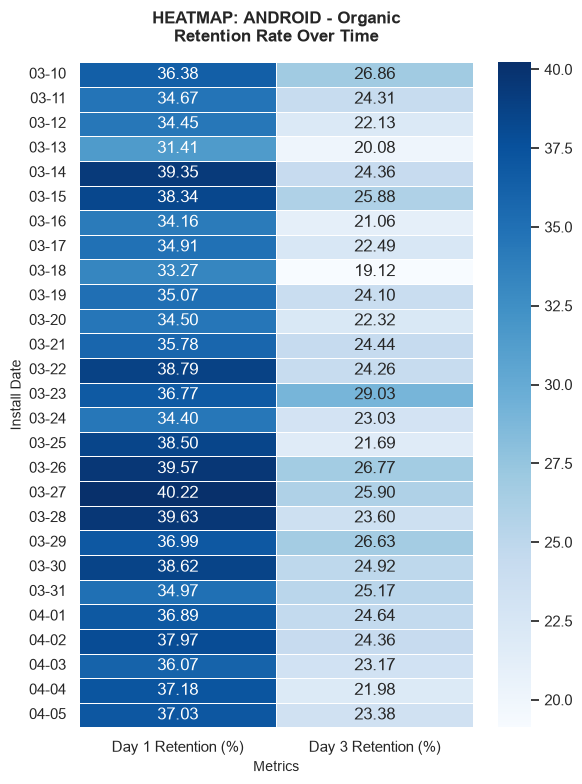

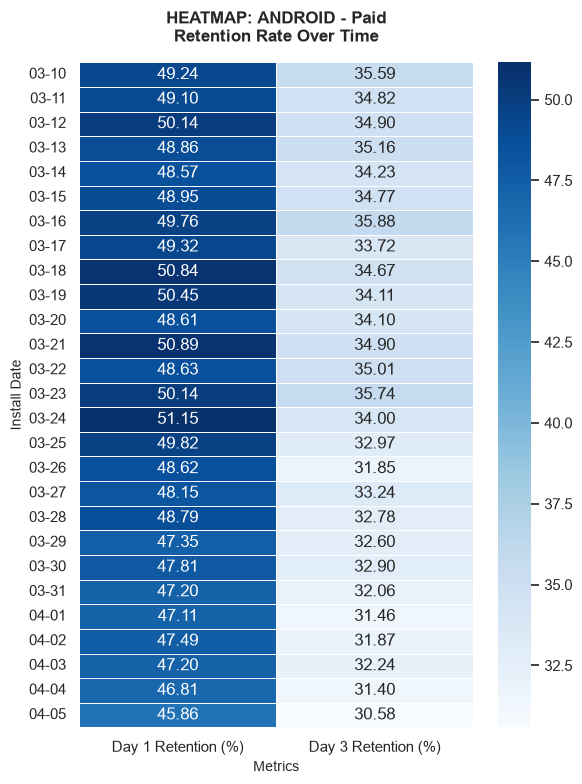

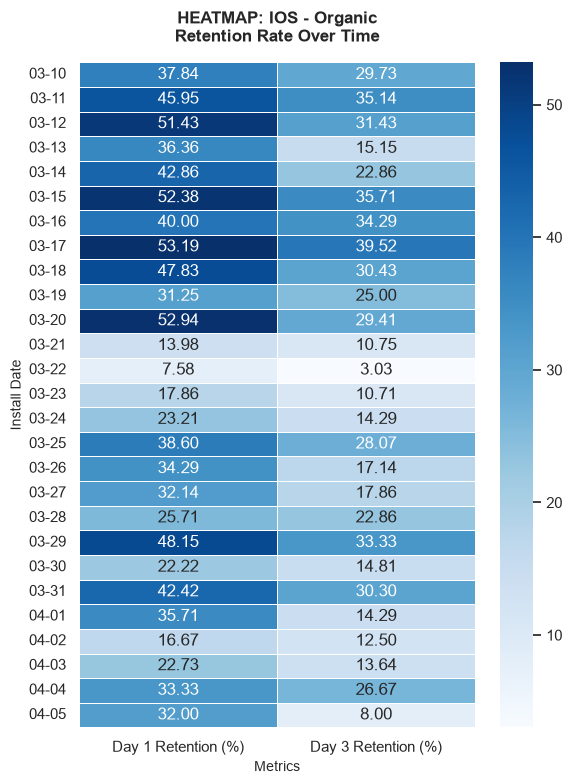

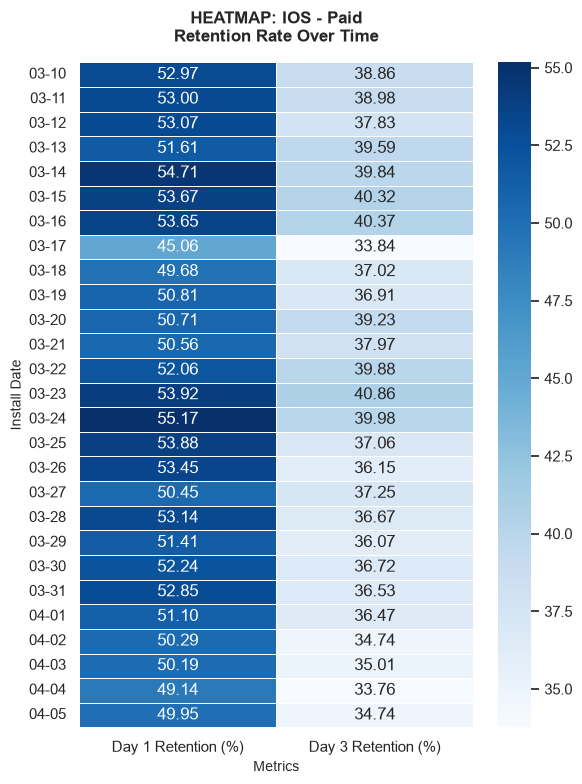

In [38]:
os_list = ['ANDROID', 'IOS']
sources = ['Organic', 'Paid']

for os_name in os_list:
    for src in sources:
        df_filtered = df_traffic[(df_traffic['os'] == os_name) & (df_traffic['traffic_source_medium'] == src)]
        pivot_data = df_filtered.pivot(index='install_date', columns='traffic_source_medium', values=['rr_d1', 'rr_d3'])
        pivot_data.columns = ['Day 1 Retention (%)', 'Day 3 Retention (%)']
        
        plt.figure(figsize=(6, 8)) 
        
        sns.heatmap(
            pivot_data, 
            annot=True,          
            fmt=".2f",           
            cmap="Blues",       
            linewidths=.5,       
            cbar=True            
        )
        
        plt.title(f'HEATMAP: {os_name} - {src}\nRetention Rate Over Time', fontsize=12, fontweight='bold', pad=15)
        plt.xlabel('Metrics', fontsize=10)
        plt.ylabel('Install Date', fontsize=10)
        
        plt.tight_layout()
        plt.show()

In [27]:
full_traffic_query = """WITH base AS (
  SELECT
    user_pseudo_id,
    install_date,
    CASE
      WHEN install_date BETWEEN '2026-03-10' AND '2026-03-23' THEN 'before'
      WHEN install_date BETWEEN '2026-03-24' AND '2026-04-05' THEN 'after'
    END AS period,
    UPPER(operating_system) AS os,
    country,
    tier,
    version,
    traffic_source_medium,
    traffic_source_source,
    _0, _1, _2, _3, _4, _5, _6, _7, _14, _30
  FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
  WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
  AND install_date IS NOT NULL
  ORDER BY install_date ASC
)

SELECT
  CASE 
    WHEN traffic_source_medium IS NULL OR traffic_source_medium IN ('Unknown Devices', 'Untrusted Devices') THEN 'Organic'
    ELSE traffic_source_medium 
  END AS traffic_source_medium,
  install_date,
  period,
  os,
  COUNT(user_pseudo_id) AS total_installs,
  SUM(_1) AS retained_d1,
  SUM(_3) AS retained_d3,
  ROUND(SAFE_DIVIDE(SUM(_1), COUNT(user_pseudo_id)) * 100, 2) AS rr_d1,
  ROUND(SAFE_DIVIDE(SUM(_3), COUNT(user_pseudo_id)) * 100, 2) AS rr_d3
FROM base
GROUP BY install_date, traffic_source_medium, period, os
ORDER BY install_date, os;
""" 
df_full_traffic = client.query(full_traffic_query).to_dataframe()

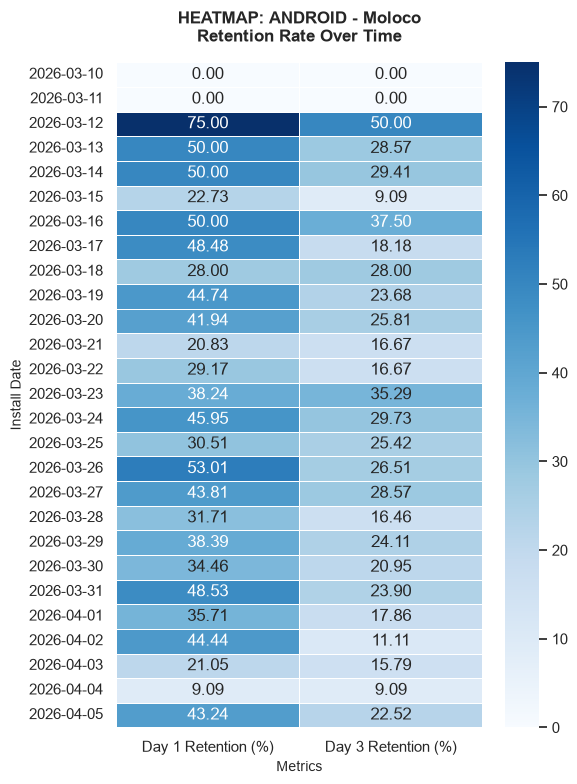

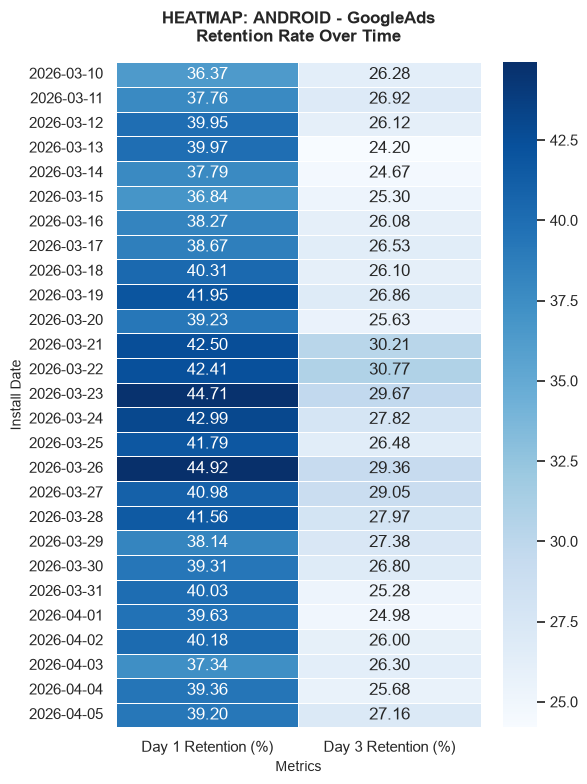

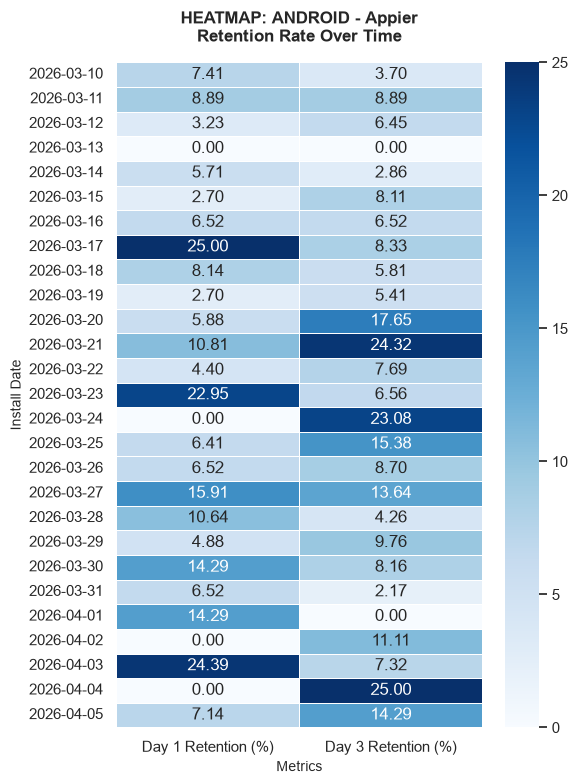

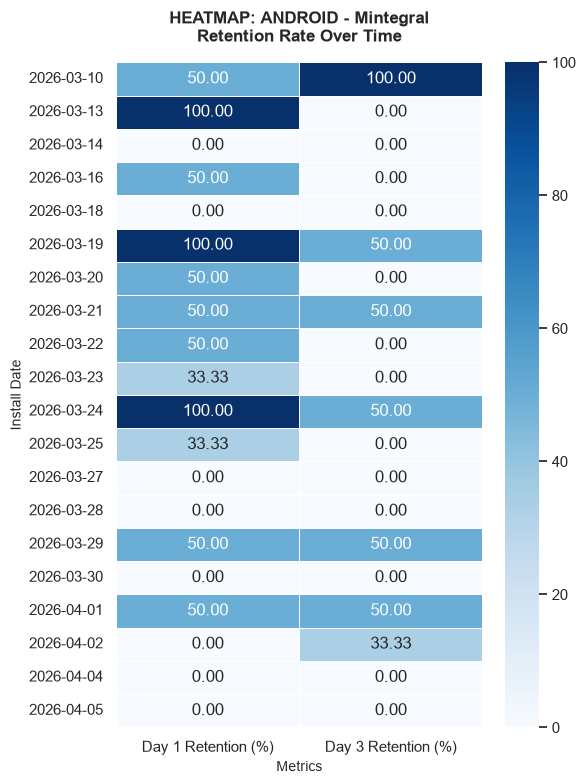

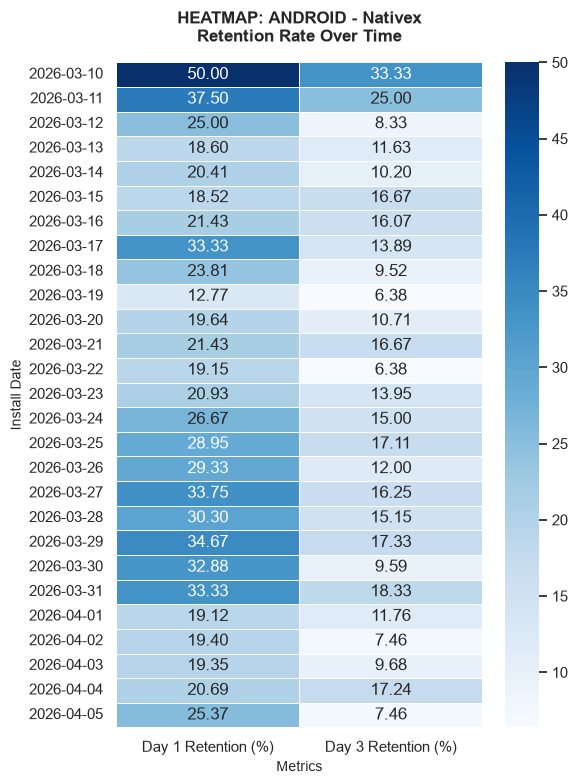

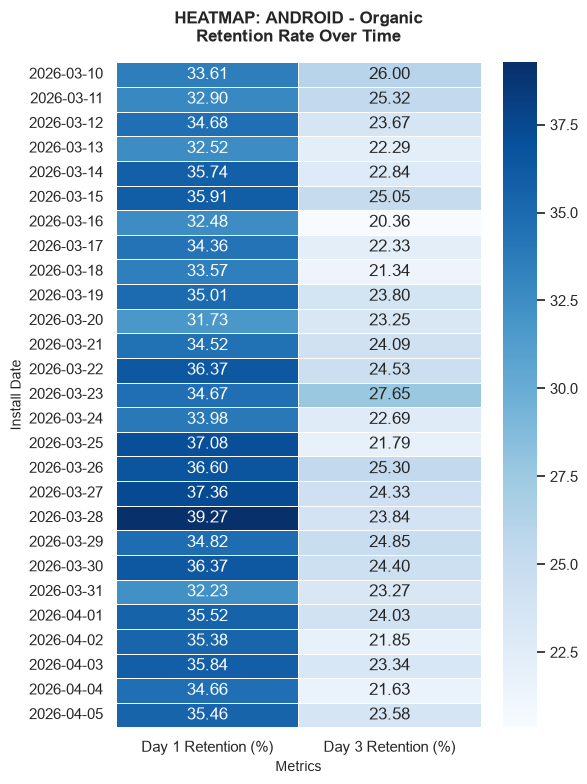

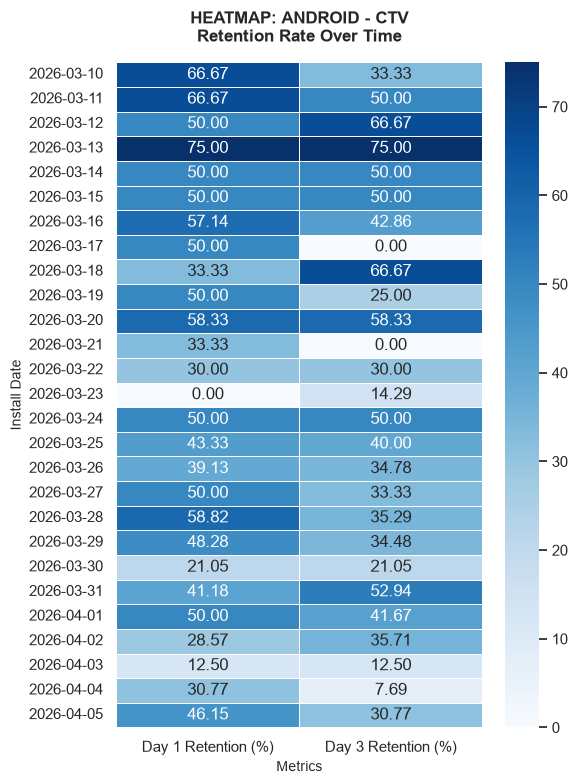

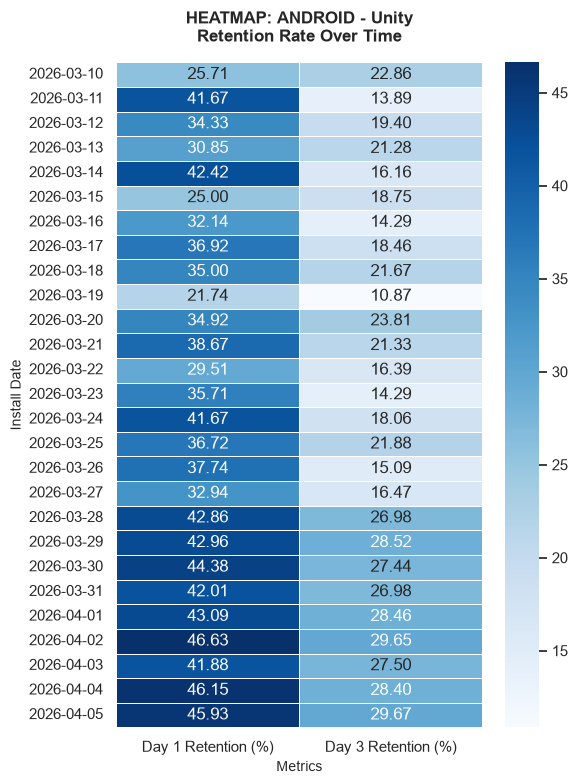

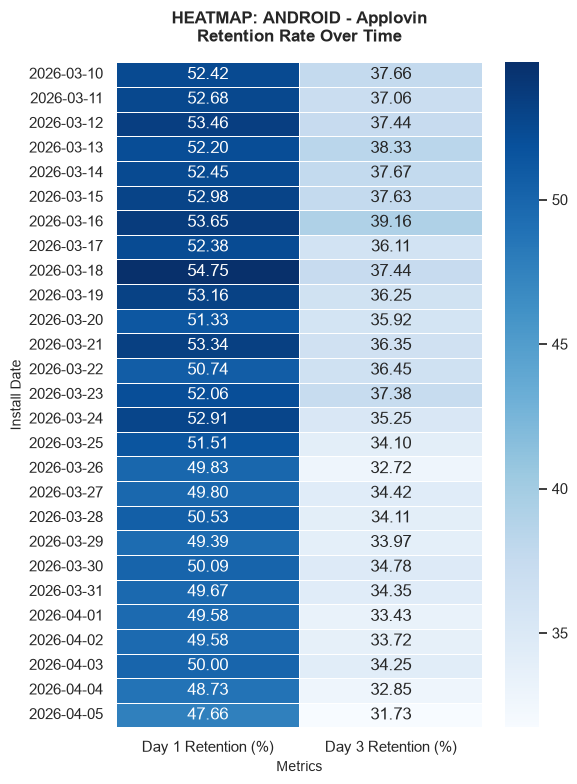

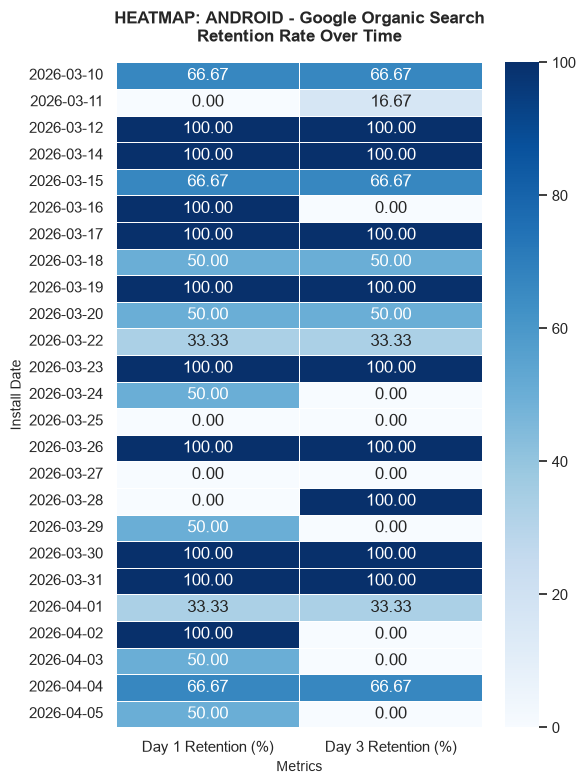

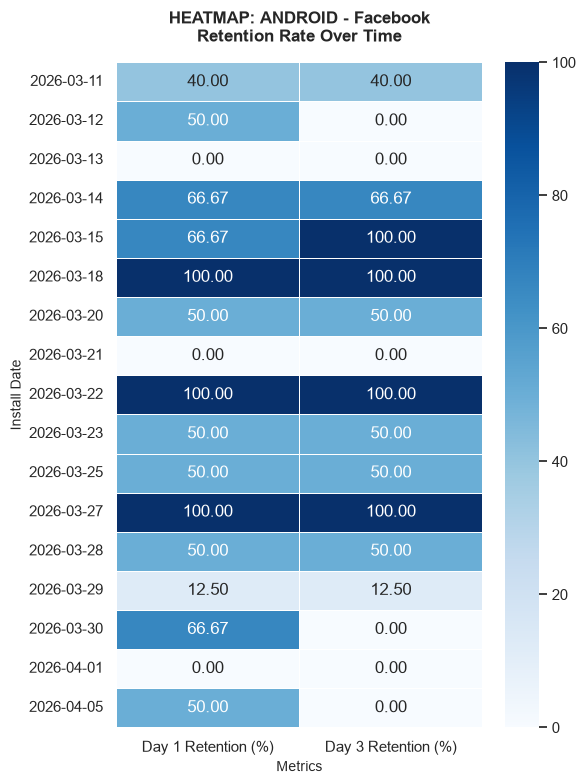

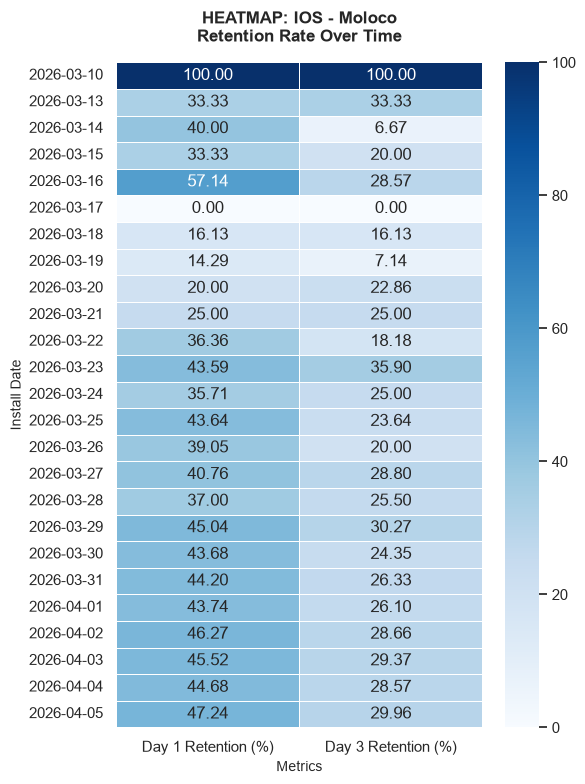

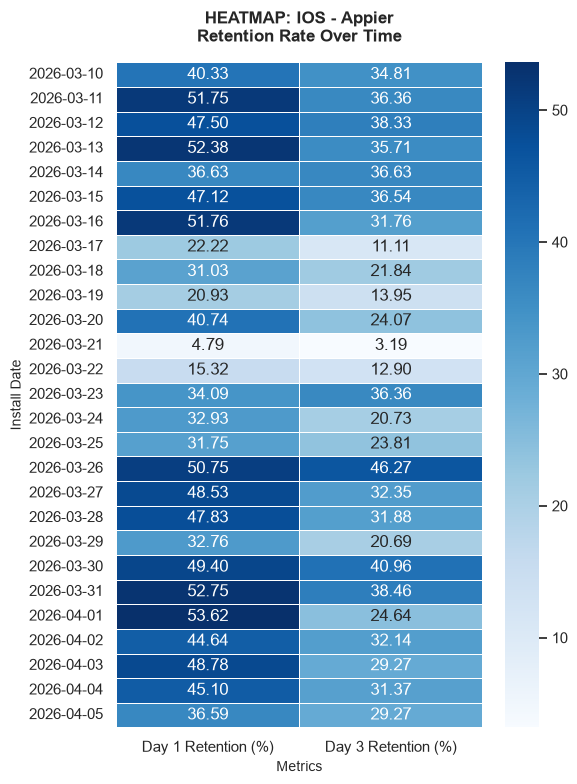

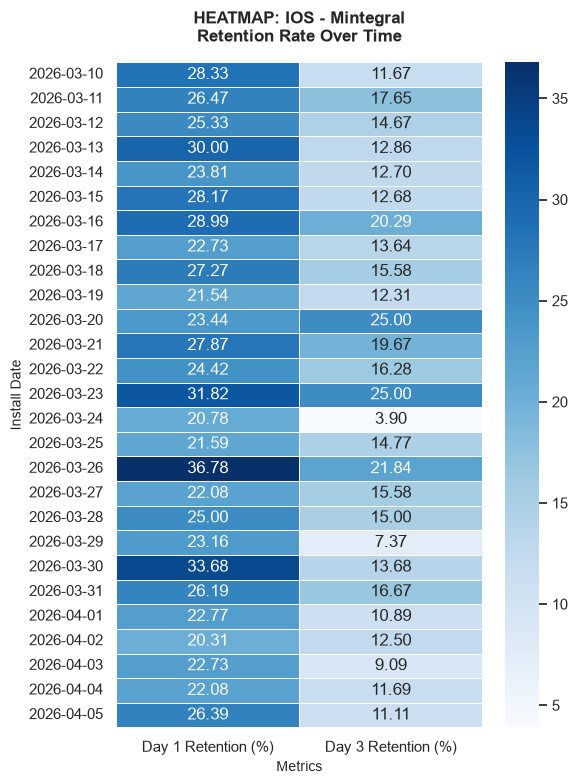

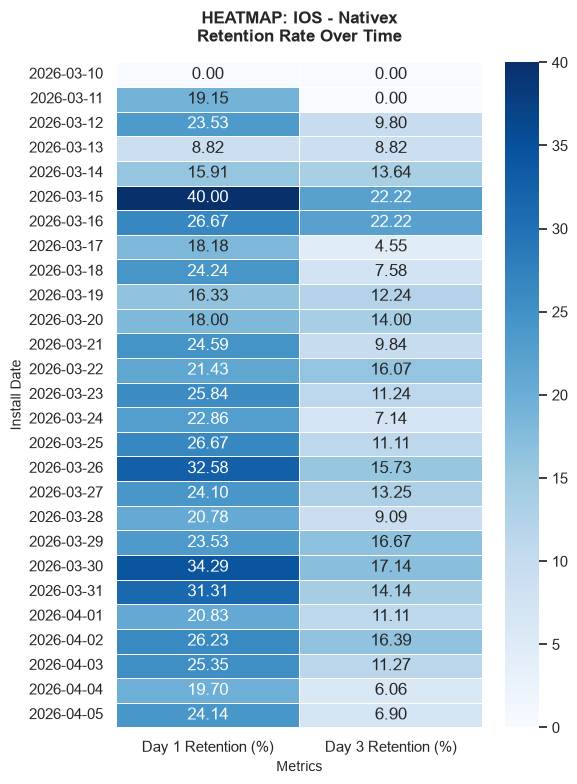

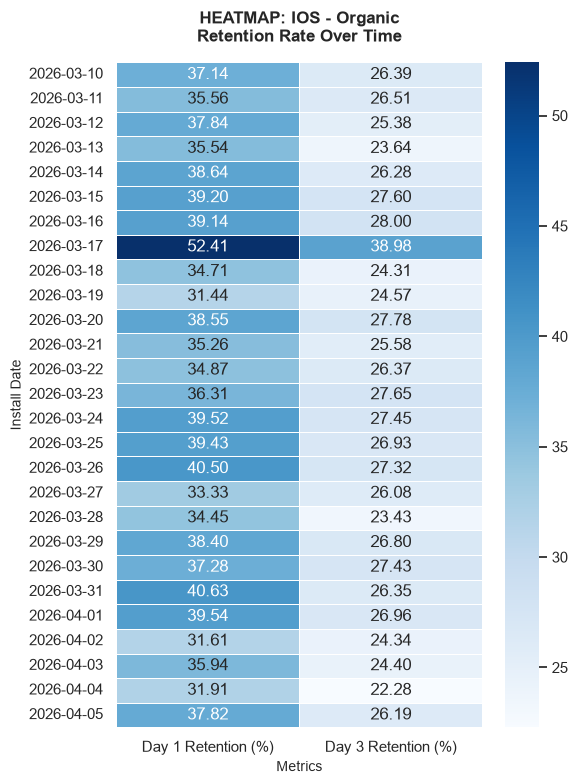

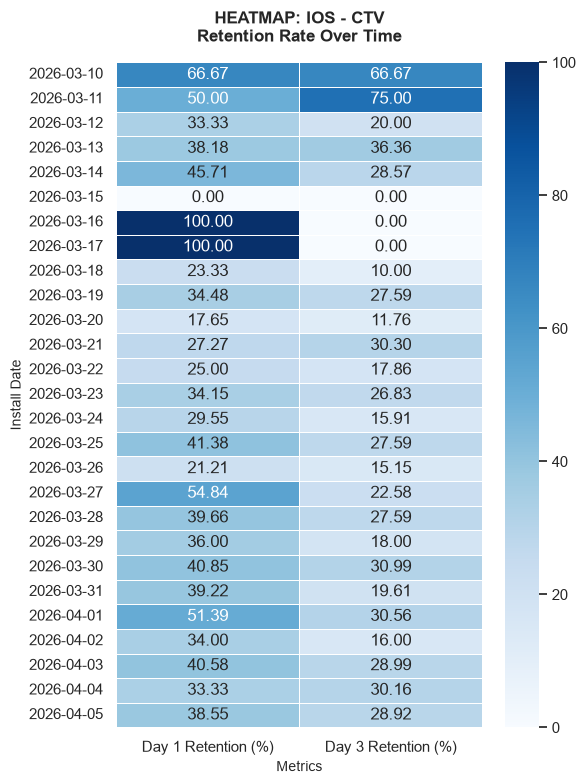

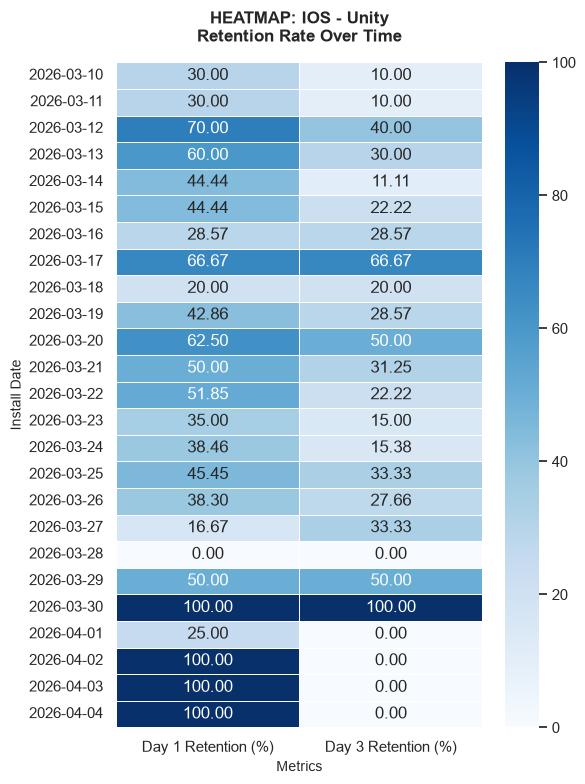

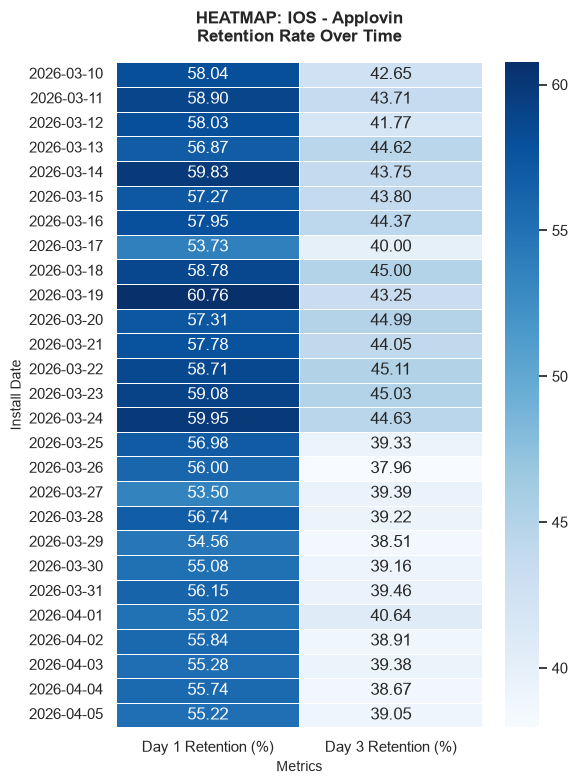

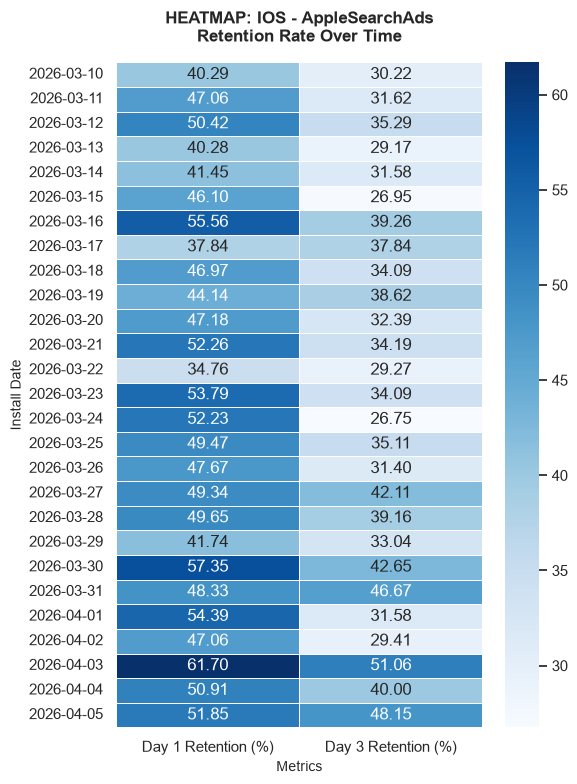

In [ ]:
sources = df_full_traffic['traffic_source_medium'].unique()

for os_name in os_list:
    for src in sources:
        df_filtered = df_full_traffic[(df_full_traffic['os'] == os_name) & (df_full_traffic['traffic_source_medium'] == src)]
        if df_filtered.empty:
            continue
        pivot_data = df_filtered.pivot(index='install_date', columns='traffic_source_medium', values=['rr_d1', 'rr_d3'])
        pivot_data.columns = ['Day 1 Retention (%)', 'Day 3 Retention (%)']
        
        plt.figure(figsize=(6, 8)) 
        
        sns.heatmap(
            pivot_data, 
            annot=True,          
            fmt=".2f",           
            cmap="Blues",       
            linewidths=.5,       
            cbar=True            
        )
        
        plt.title(f'HEATMAP: {os_name} - {src}\nRetention Rate Over Time', fontsize=12, fontweight='bold', pad=15)
        plt.xlabel('Metrics', fontsize=10)
        plt.ylabel('Install Date', fontsize=10)
        
        plt.tight_layout()
        plt.show()

In [48]:
# --- Khởi tạo chuỗi chứa nội dung HTML với CSS cơ bản ---
html_content = """<!DOCTYPE html>
<html lang="vi">
<head>
    <meta charset="UTF-8">
    <title>Báo cáo Retention Rate</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f9f9f9; }
        .card { background: white; padding: 20px; margin-bottom: 30px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
        h3 { color: #333; margin-top: 0; }
        
        /* Định dạng bảng Pandas */
        table { width: 100%; border-collapse: collapse; margin-top: 10px; text-align: center; }
        th { background-color: #007bff; color: white; padding: 10px; border: 1px solid #ddd; }
        td { padding: 8px; border: 1px solid #ddd; }
        tr:nth-child(even) { background-color: #f2f2f2; } /* Màu xen kẽ các dòng cho dễ nhìn */
    </style>
</head>
<body>
<h2>BÁO CÁO RETENTION RATE</h2>
"""

sources = df_full_traffic["traffic_source_medium"].unique()

for os_name in os_list:
    for src in sources:
        df_filtered = df_full_traffic[
            (df_full_traffic["os"] == os_name)
            & (df_full_traffic["traffic_source_medium"] == src)
        ]
        if df_filtered.empty:
            continue

        pivot_data = df_filtered.pivot(
            index="install_date",
            columns="traffic_source_medium",
            values=["rr_d1", "rr_d3"],
        )
        pivot_data.columns = ["Day 1 Retention (%)", "Day 3 Retention (%)"]

        # Đảo ngược thứ tự ngày (ngày mới nhất lên đầu)
        pivot_data = pivot_data.reindex(index=pivot_data.index[::-1])

        # --- DÙNG TO_HTML NGUYÊN BẢN (Không cần .style, không cần jinja2) ---
        html_table = pivot_data.to_html()

        # Gom bảng vào thẻ div
        html_content += f"""
        <div class="card">
            <h3>HEATMAP: {os_name} - {src}</h3>
            {html_table}
        </div>
        """

html_content += """
</body>
</html>
"""

# --- Ghi ra file HTML ---
with open("report_dongian.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("Đã xuất file report_dongian.html thành công!")

Đã xuất file report_dongian.html thành công!


---

In [23]:
# Tính RR chung
rr_query = """SELECT
    install_date,
    UPPER(operating_system) AS os,
    COUNT(user_pseudo_id) AS total_installs,
    SUM(_1) AS retained_d1,
    SUM(_3) AS retained_d3,
    SUM(_7) AS retained_d7,
    ROUND(SAFE_DIVIDE(SUM(_1), COUNT(user_pseudo_id)) * 100, 2) AS rr_d1_pct,
    ROUND(SAFE_DIVIDE(SUM(_3), COUNT(user_pseudo_id)) * 100, 2) AS rr_d3_pct,
    ROUND(SAFE_DIVIDE(SUM(_7), COUNT(user_pseudo_id)) * 100, 2) AS rr_d7_pct
FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
GROUP BY install_date, os
ORDER BY install_date ASC, os ASC;
"""
df_rr = client.query(rr_query).to_dataframe()
display(df_rr)

,install_date,os,total_installs,retained_d1,retained_d3,retained_d7,rr_d1_pct,rr_d3_pct,rr_d7_pct
0,2026-03-10,ANDROID,8268,4004,2897,2241,48.43,35.04,27.10
1,2026-03-10,IOS,4445,2349,1724,1365,52.85,38.79,30.71
2,2026-03-11,ANDROID,6756,3249,2303,1821,48.09,34.09,26.95
3,2026-03-11,IOS,4160,2202,1620,1270,52.93,38.94,30.53
4,2026-03-12,ANDROID,6691,3280,2274,1807,49.02,33.99,27.01
5,2026-03-12,IOS,4077,2163,1540,1206,53.05,37.77,29.58
6,2026-03-13,ANDROID,6094,2890,2067,1567,47.42,33.92,25.71
7,2026-03-13,IOS,4112,2117,1620,1210,51.48,39.40,29.43
8,2026-03-14,ANDROID,6768,3233,2259,1813,47.77,33.38,26.79
9,2026-03-14,IOS,4842,2645,1923,1504,54.63,39.71,31.06


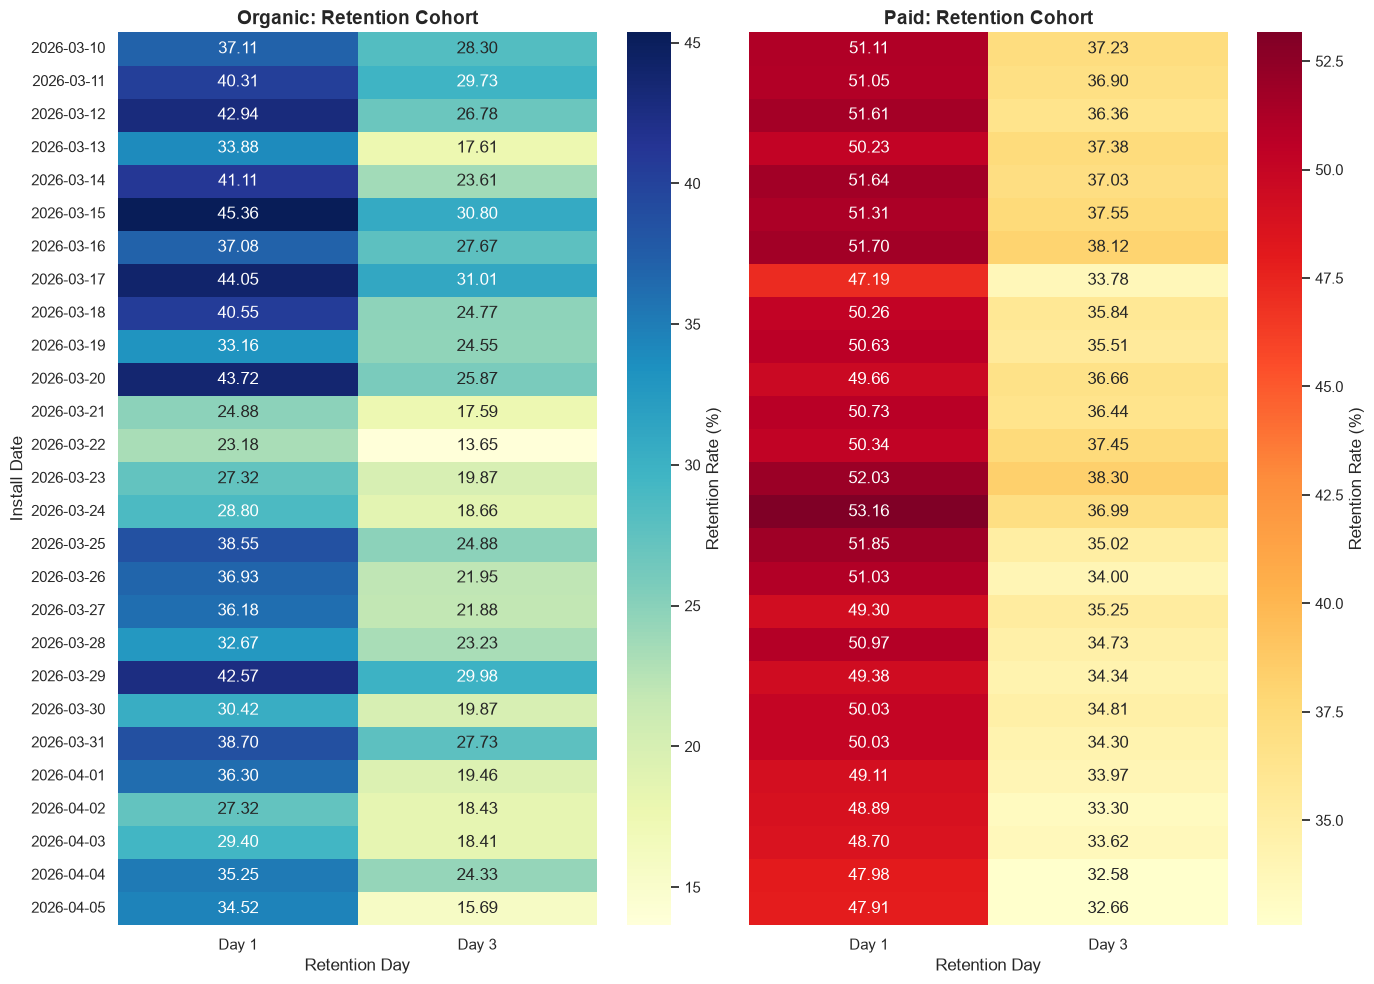

In [ ]:
# Tính RR riêng cho từng Tier
rr_tier_query = """SELECT
    install_date,
    UPPER(operating_system) AS os,
    CASE 
        WHEN tier = 'Tier01' THEN 'Tier 1'
        WHEN tier = 'Tier02' THEN 'Tier 2'
        WHEN tier = 'Tier03' THEN 'Tier 3'
        ELSE 'Tier 4'
    END AS tier_group,
    COUNT(user_pseudo_id) AS total_installs,
    SUM(_3) AS retained_d3,
    ROUND(SAFE_DIVIDE(SUM(_3), COUNT(user_pseudo_id)) * 100, 2) AS rr_d3_pct
FROM `bi-recruitment-452004.ef_capstone.retention_cohort`
WHERE install_date BETWEEN '2026-03-10' AND '2026-04-05'
GROUP BY install_date, os, tier_group
ORDER BY install_date ASC, os ASC, tier_group ASC;
""" 
df_rr_tier = client.query(rr_tier_query).to_dataframe()
display(df_rr_tier)

,install_date,os,tier_group,total_installs,retained_d3,rr_d3_pct
0,2026-03-10,ANDROID,Tier 1,1675,557,33.25
1,2026-03-10,ANDROID,Tier 2,1378,515,37.37
2,2026-03-10,ANDROID,Tier 3,3171,1072,33.81
3,2026-03-10,ANDROID,Tier 4,2044,753,36.84
4,2026-03-10,IOS,Tier 1,2132,794,37.24
5,2026-03-10,IOS,Tier 2,729,282,38.68
6,2026-03-10,IOS,Tier 3,1246,504,40.45
7,2026-03-10,IOS,Tier 4,338,144,42.60
8,2026-03-11,ANDROID,Tier 1,1416,465,32.84
9,2026-03-11,ANDROID,Tier 2,1215,460,37.86


- Cấu trúc install volume trước thay đổi (10–19/03):
    - Android: Tier 1 chiếm 20.6%, Tier 2 16.8%, Tier 3 38%, Tier 4 24.6% - tổng 73,647 install.
    - iOS: Tier 1 chiếm 46.3%, Tier 2 16.5%, Tier 3 28.9%, Tier 4 8.3% - tổng 40,055 install.

=> iOS có cấu trúc Tier 1 rất nặng (gần một nửa install từ 5 nước Tier 1), trong khi Android phân tán hơn và Tier 3/4 chiếm phần lớn.

In [ ]:
# Số lượng country theo từng tier

count_country_query = """SELECT 
  tier,
  COUNT(DISTINCT country) AS total_country
FROM `bi-recruitment-452004.ef_capstone.retention_cohort` 
GROUP BY tier
ORDER BY tier;
"""
display(client.query(count_country_query).to_dataframe())

,tier,total_country
0,NaN,5
1,Tier01,5
2,Tier02,16
3,Tier03,51
4,Tier04,116


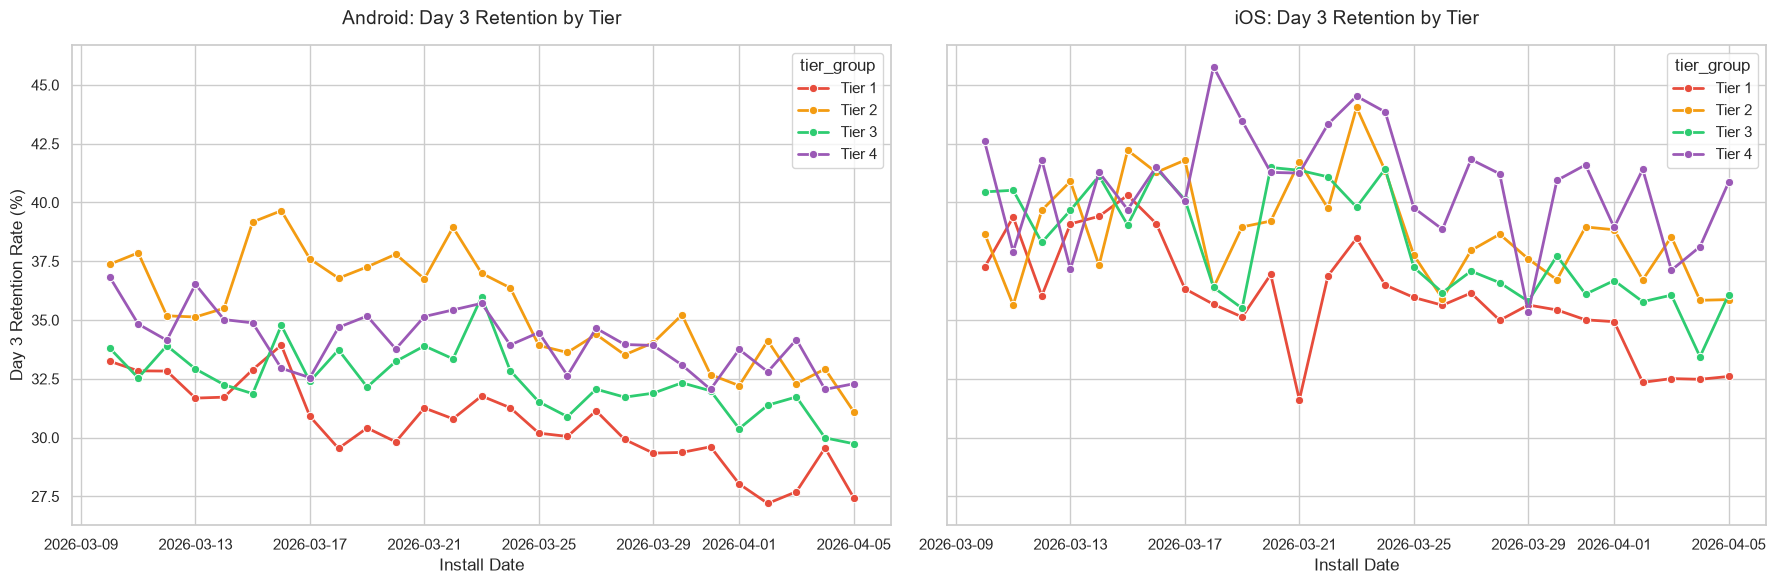

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

df_android = df_rr_tier[df_rr_tier['os'] == 'ANDROID']
df_ios = df_rr_tier[df_rr_tier['os'] == 'IOS']

sns.lineplot(data=df_android, x='install_date', y='rr_d3_pct', hue='tier_group', 
             marker='o', linewidth=2, ax=axes[0], 
             palette=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6']) 
axes[0].set_title('Android: Day 3 Retention by Tier', fontsize=14, pad=15)
axes[0].set_xlabel('Install Date', fontsize=12)
axes[0].set_ylabel('Day 3 Retention Rate (%)', fontsize=12)

sns.lineplot(data=df_ios, x='install_date', y='rr_d3_pct', hue='tier_group', 
             marker='o', linewidth=2, ax=axes[1], 
             palette=['#E74C3C', '#F39C12', '#2ECC71', '#9B59B6'])
axes[1].set_title('iOS: Day 3 Retention by Tier', fontsize=14, pad=15)
axes[1].set_xlabel('Install Date', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()